<a href="https://colab.research.google.com/github/SmitPatil2004/gearbox-fault-detection-uct/blob/main/02_gearbox_feature_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 — Re-extract the data

In [2]:
import zipfile
from pathlib import Path

OUTER = next(Path('/content').glob('*.zip'))
with zipfile.ZipFile(OUTER) as z:
    z.extractall('/content/outer')

inner = next(Path('/content/outer').rglob('*.zip'))
DEST = Path('/content/gearbox_data')
with zipfile.ZipFile(inner) as z:
    z.extractall(DEST)

files = sorted(DEST.rglob('*.txt'))
print('Data files found:', len(files))

Data files found: 20


Step 2 — The reader function

In [3]:
import pandas as pd
import numpy as np
import re

COLS = ['a1', 'a2', 'a3', 'a4']

def read_file(path):
    return pd.read_csv(path, sep='\t', header=None, skiprows=1,
                       usecols=[0, 1, 2, 3], names=COLS)

sample = read_file(files[0])
print(sample.shape)
sample.head()

(88320, 4)


,a1,a2,a3,a4
0,2.350390,1.454870,-1.667080,-2.055610
1,2.452970,1.400100,-2.825100,0.984487
2,-0.241284,-0.267390,0.793540,0.605862
3,1.130270,-0.890918,0.696969,0.613068
4,-1.296140,0.980479,-1.130560,-0.346971


Step 3 — The windowing function

In [4]:
W = 1000     # window size

def windowize(d, W):
    n = (len(d) // W) * W          # trim the leftover partial window
    d = d.iloc[:n]
    g = np.arange(n) // W          # 0,0,0...,1,1,1...,2,2,2...

    grp = d.groupby(g)
    rms = (d ** 2).groupby(g).mean() ** 0.5

    return pd.concat([
        grp.mean().add_suffix('_mean'),
        grp.std().add_suffix('_std'),
        grp.min().add_suffix('_min'),
        grp.max().add_suffix('_max'),
        rms.add_suffix('_rms'),
    ], axis=1)

test_out = windowize(read_file(files[0]), W)
print(test_out.shape)
test_out.head()

(88, 20)


,a1_mean,a2_mean,a3_mean,a4_mean,a1_std,a2_std,a3_std,a4_std,a1_min,a2_min,a3_min,a4_min,a1_max,a2_max,a3_max,a4_max,a1_rms,a2_rms,a3_rms,a4_rms
0,0.022667,0.050447,0.017087,0.067451,3.656871,3.799301,3.196925,2.975637,-16.3548,-16.5693,-11.0462,-9.38014,14.0705,12.0868,12.2018,13.4877,3.655112,3.797736,3.195372,2.974914
1,-0.010693,-0.015491,0.015504,-0.898388,3.514451,4.051340,3.116087,4.032697,-14.2036,-14.0839,-10.9297,-18.89410,12.0625,14.5813,10.3752,14.2102,3.512710,4.049344,3.114567,4.129587
2,0.024794,0.025971,0.041604,0.513946,3.482452,3.666036,3.017378,3.303988,-13.6001,-16.0745,-11.4722,-16.19960,19.0489,14.6743,12.0693,14.3429,3.480799,3.664294,3.016155,3.342089
3,0.022342,0.047822,0.024972,0.134607,3.123445,3.338053,2.667693,2.614247,-11.0787,-12.6343,-10.1331,-11.52320,11.9852,15.5054,11.3805,10.6889,3.121963,3.336726,2.666475,2.616405
4,0.001597,-0.010211,0.004157,-0.200254,3.467991,4.119875,3.275492,3.339113,-11.3939,-15.2606,-11.2162,-14.96600,10.6377,14.2808,15.4648,11.9976,3.466257,4.117827,3.273857,3.343445


Step 4 — Process all 20 files

In [5]:
frames = []

for p in files:
    feats = windowize(read_file(p), W)
    feats['condition'] = 'Healthy' if 'Healthy' in p.parent.name else 'BrokenTooth'
    feats['load'] = int(re.search(r'hz(\d+)', p.stem).group(1))
    feats['file'] = p.name
    frames.append(feats)

data = pd.concat(frames, ignore_index=True)

print('Final shape:', data.shape)
print('Missing values:', data.isnull().sum().sum())
data.head()

Final shape: (2009, 23)
Missing values: 0


,a1_mean,a2_mean,a3_mean,a4_mean,a1_std,a2_std,a3_std,a4_std,a1_min,a2_min,...,a2_max,a3_max,a4_max,a1_rms,a2_rms,a3_rms,a4_rms,condition,load,file
0,0.022667,0.050447,0.017087,0.067451,3.656871,3.799301,3.196925,2.975637,-16.3548,-16.5693,...,12.0868,12.2018,13.4877,3.655112,3.797736,3.195372,2.974914,BrokenTooth,0,b30hz0.txt
1,-0.010693,-0.015491,0.015504,-0.898388,3.514451,4.051340,3.116087,4.032697,-14.2036,-14.0839,...,14.5813,10.3752,14.2102,3.512710,4.049344,3.114567,4.129587,BrokenTooth,0,b30hz0.txt
2,0.024794,0.025971,0.041604,0.513946,3.482452,3.666036,3.017378,3.303988,-13.6001,-16.0745,...,14.6743,12.0693,14.3429,3.480799,3.664294,3.016155,3.342089,BrokenTooth,0,b30hz0.txt
3,0.022342,0.047822,0.024972,0.134607,3.123445,3.338053,2.667693,2.614247,-11.0787,-12.6343,...,15.5054,11.3805,10.6889,3.121963,3.336726,2.666475,2.616405,BrokenTooth,0,b30hz0.txt
4,0.001597,-0.010211,0.004157,-0.200254,3.467991,4.119875,3.275492,3.339113,-11.3939,-15.2606,...,14.2808,15.4648,11.9976,3.466257,4.117827,3.273857,3.343445,BrokenTooth,0,b30hz0.txt


Step 5 — Verify class balance **survived**

In [7]:
print(data['condition'].value_counts(), '\n')
print(pd.crosstab(data['load'], data['condition']))

condition
Healthy        1009
BrokenTooth    1000
Name: count, dtype: int64 

condition  BrokenTooth  Healthy
load                           
0                   88       88
10                 111       92
20                 114      108
30                  89      106
40                  94      100
50                  94      110
60                  95       99
70                 100      101
80                 110       99
90                 105      106


Step 6 — Confirm no leakage

In [6]:
FEATURES = [c for c in data.columns if c not in ['condition', 'load', 'file']]

print('Number of features:', len(FEATURES))
print(FEATURES)

Number of features: 20
['a1_mean', 'a2_mean', 'a3_mean', 'a4_mean', 'a1_std', 'a2_std', 'a3_std', 'a4_std', 'a1_min', 'a2_min', 'a3_min', 'a4_min', 'a1_max', 'a2_max', 'a3_max', 'a4_max', 'a1_rms', 'a2_rms', 'a3_rms', 'a4_rms']


Step 7 — The splitting problem

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GroupKFold

X, y, groups = data[FEATURES], data['condition'], data['file']
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

random_cv  = cross_val_score(model, X, y, cv=5).mean()
grouped_cv = cross_val_score(model, X, y, cv=GroupKFold(5), groups=groups).mean()

print(f'Random 5-fold CV:      {random_cv:.4f}')
print(f'Grouped by file CV:    {grouped_cv:.4f}')

Random 5-fold CV:      0.9970
Grouped by file CV:    0.9970


Step 8 — A quick look at what separates the classes

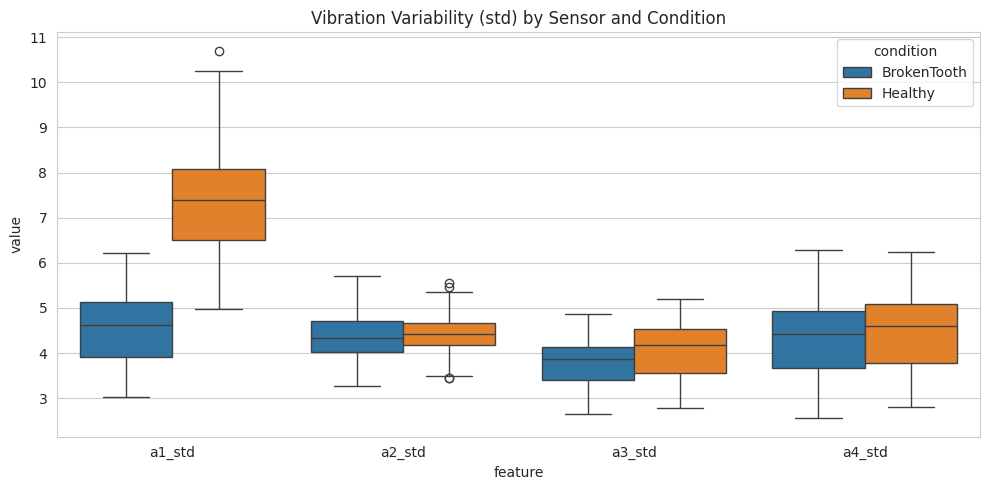

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

std_cols = [c for c in FEATURES if c.endswith('_std')]
melted = data.melt(id_vars='condition', value_vars=std_cols,
                   var_name='feature', value_name='value')

plt.figure(figsize=(10, 5))
sns.boxplot(data=melted, x='feature', y='value', hue='condition')
plt.title('Vibration Variability (std) by Sensor and Condition')
plt.tight_layout()
plt.savefig('03_std_by_condition.png', dpi=120, bbox_inches='tight')
plt.show()

Step 9 — Save the feature table

In [10]:
data.to_csv('gearbox_features.csv', index=False)
print('Saved:', data.shape)

Saved: (2009, 23)
